In [1]:
#| default_exp model_zoo

## Models zoo

### Univariate forecasters

All models share a consistent interface — each accepts a target_col to specify the target series, along with any model-specific parameters. Fitting is done via .fit(df) and forecasting via .forecast(H). Exogenous variables, where supported, are passed at the forecasting step and aligned automatically. All models also expose .cross_validate() for evaluation, supporting both expanding and sliding window strategies with a configurable step size.

The table below summarises the available univariate forecasters, from simple baselines to statistical and machine learning models, along with a minimal usage example for each.

| **Models** | **Description** | **Usage Example** |
|----------|-----------|---------------|
| Naive Forecaster | A simple forecasting model that uses the last observed value or last seasonal value as the forecast. | <code> from peshbeen.models import naive <br> model = naive(target_col='target column name', season_period=None) <br> model.fit(df) <br> forecasts = model.forecast(H=10)|
| ETS (Exponential Smoothing state space models) | ETS forecaster that wraps the `statsmodels` implementation, allowing for easy integration and forecasting. | <code> from peshbeen.models import ets <br> model = ets(target_col='target column name', trend='add', seasonal='add', seasonal_periods=12, smoothing_level=0.1, smoothing_trend=0.1, smoothing_seasonal=0.1) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |
| ARIMA (AutoRegressive Integrated Moving Average) | ARIMA — a fast, familiar forecaster backed by Nixtla's `statsforecast` implementation, the fastest ARIMA in Python. | <code> from peshbeen.models import arima <br> model = arima(target_col='target column name', order=(1, 1, 1)) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |
| Machine Learning Regressors — any scikit-learn-compatible regressor, from LinearRegression, RandomForest and AdaBoost to XGBoost, LightGBM, and CatBoost. | A unified forecasting wrapper for any compatible regression model. | <code> from peshbeen.models import ml_forecaster <br> from sklearn.ensemble import RandomForestRegressor <br> model = ml_forecaster(target_col='target column name', estimator=RandomForestRegressor(n_estimators=100)) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |
| MS-ARR (Markov-Switching AutoRegressive Regression) | Models time series with hidden regime changes (e.g. recession vs. growth, low vs. high volatility) using autoregressive dynamics and optional exogenous variables. | <code>  from peshbeen.models import ms_arr <br> model = ms_arr(target_col='target column name', n_components=2, lags = 2, n_iter=100) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |
| GLM (Generalized Linear Models) | A statsmodels-backed generalization of linear regression that supports non-Gaussian response distributions — including Poisson for count data and Gamma for strictly positive, skewed data. | <code> from peshbeen.models import glm <br> model = glm(target_col='target column name', family='poisson', lags=2) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |

### Multivariate forecasters

| **Models** | **Description** | **Usage Example** |
|----------|-----------|---------------|
| VAR (Vector AutoRegression) | A pure-NumPy multivariate forecaster that models linear interdependencies across multiple time series, with per-series lag structure control. | <code> from peshbeen.models import var <br> model = var(target_cols=['target column 1', 'target column 2'], lags={'target column 1': 2, 'target column 2': [1, 2, 7]}) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |
| Machine Learning Regressors (multivariate) — any scikit-learn-compatible regressor, from LinearRegression and RandomForest to XGBoost, LightGBM, and CatBoost. | Forecasts multiple series simultaneously by leveraging interdependencies among them, using any scikit-learn-compatible regressor. | <code> from peshbeen.models import ml_mv_forecaster <br> from lightgbm import LGBMRegressor <br> model = ml_mv_forecaster(target_cols=['target column 1', 'target column 2'], estimator=LGBMRegressor(n_estimators=100, learning_rate=0.1), lags={'target column 1': 2, 'target column 2': [1, 2, 7]}) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |
| MS-VAR (Markov-Switching Vector AutoRegression) | A multivariate extension of MS-ARR that models multiple time series with hidden regime changes using vector autoregressive dynamics and optional exogenous variables. | <code> from peshbeen.models import ms_var <br> model = ms_var(target_cols=['target column 1', 'target column 2'], n_components=2, lags={'target column 1': 2, 'target column 2': [1, 2, 7]}, n_iter=100) <br> model.fit(df) <br> forecasts = model.forecast(H=10) |

In [1]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# date_range = pd.date_range(start='2020-01-01', periods=720, freq='D')
# # create a non-stationary arbitrary flower sales data with an upward trend, weekly seasonality, and yearly seasonality
# np.random.seed(42)
# data = 30 + 0.07 * np.arange(720) + 10 * np.sin(2 * np.pi * date_range.dayofyear / 7) + 10 * np.sin(2 * np.pi * date_range.dayofyear / 365) + np.random.normal(0, 5, 720)

# sales_data = pd.DataFrame(data, index=date_range, columns=['sales'])

**Example for multivariate forecasting works using the `VAR` model.**

Peshbeen's `VAR` model allows you to specify different lag structures for each target series, enabling you to capture the unique temporal dependencies of each series while modeling their interdependencies. Different than the implementation of the standard VAR in `statsmodels`, which applies the same lag structure to all series, Peshbeen's `VAR` can have, for example, one series with 2 lags and another with 1, 2, and 7 lags. This flexibility allows user to tailor the model to the specific characteristics of each series, improving forecasting performance.

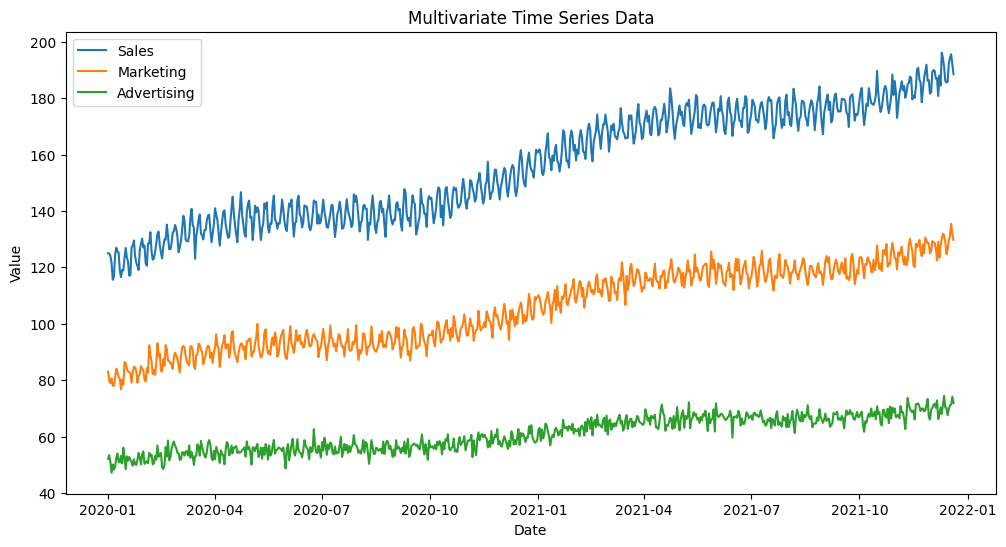

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
## Create a multivariate autoregressive sales data with 3 features: sales, marketing spend, and advertising spend to show if we can capture the relationships between past values of all three features to forecast the future values of sales. 
date_range = pd.date_range(start='2020-01-01', periods=720, freq='D')
np.random.seed(42)
doy = date_range.dayofyear.to_numpy()  # force NumPy, not pandas Index
data1 = 120 + 0.1 * np.arange(720) + 5 * np.sin(2 * np.pi * doy / 7) + 6 * np.sin(2 * np.pi * doy / 365) + np.random.normal(0, 2, 720)
data2 = 80 + 0.07 * np.arange(720) + 3 * np.sin(2 * np.pi * doy / 7) + 4 * np.sin(2 * np.pi * doy / 365) + np.random.normal(0, 2, 720)
data3 = 50 + 0.03 * np.arange(720) + 1 * np.sin(2 * np.pi * doy / 7) + 2 * np.sin(2 * np.pi * doy / 365) + np.random.normal(0, 2, 720)

# create a multivariate dataset

multivariate_data = pd.DataFrame({'sales': data1, 'marketing': data2, 'advertising': data3}, index=date_range)

## add the day of week and month as categorical variables to the multivariate dataset
multivariate_data["day_of_week"] = multivariate_data.index.dayofweek
multivariate_data["month"] = multivariate_data.index.month

# plot the multivariate data
plt.figure(figsize=(12, 6))
plt.plot(multivariate_data.index, multivariate_data['sales'], label='Sales')
plt.plot(multivariate_data.index, multivariate_data['marketing'], label='Marketing')
plt.plot(multivariate_data.index, multivariate_data['advertising'], label='Advertising')
plt.title('Multivariate Time Series Data')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

In [3]:

from peshbeen.models import var
#split the data into train and test sets 
mv_train_data = multivariate_data.iloc[:-60]
mv_test_data = multivariate_data.iloc[-60:]

# we can specify different lag structures for each target series, enabling us to capture the unique temporal dependencies of each series while modeling their interdependencies.
# This flexibility allows user to tailor the model to the relationships between the series, improving forecasting performance.
var_model =var(target_cols=['sales', 'marketing', 'advertising'], lags={'sales': 7, 'marketing': [1, 7], 'advertising': 5},
               cat_variables=['day_of_week', 'month'])
var_model.fit(mv_train_data)
var_forecasts = var_model.forecast(H=60, exog=mv_test_data[['day_of_week', 'month']])

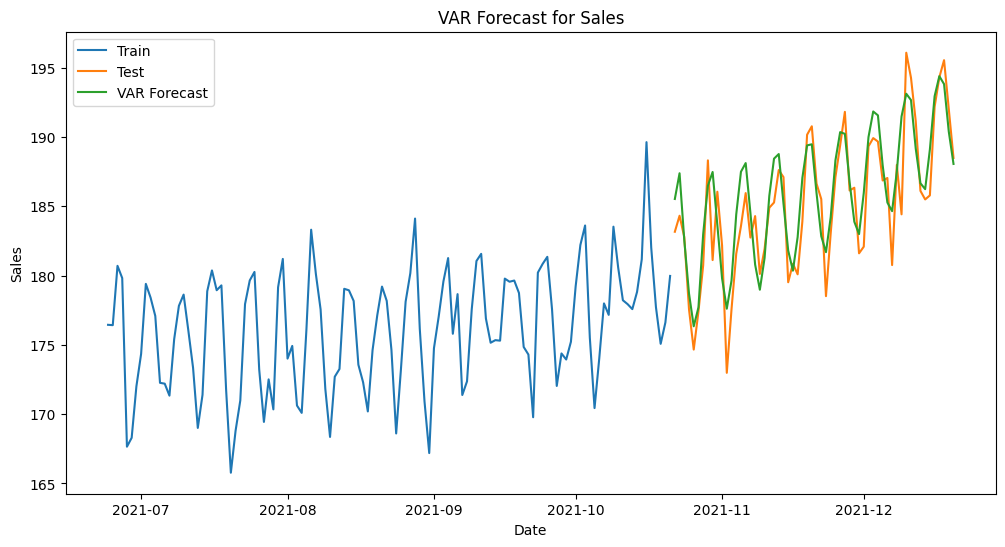

In [4]:
# plot the forecasts and the actual values for sales
plt.figure(figsize=(12, 6))
plt.plot(mv_train_data.index[-120:], mv_train_data['sales'][-120:], label='Train')
plt.plot(mv_test_data.index, mv_test_data['sales'], label='Test')
plt.plot(mv_test_data.index, var_forecasts['sales'], label='VAR Forecast')
plt.title('VAR Forecast for Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

**Example for multivariate forecasting works using machine learning regressors.**
As with the `VAR` model, Peshbeen's multivariate machine learning forecaster allows you to specify different lag structures or set of transformations for each target series, enabling you to capture the unique temporal dependencies of each series while modeling their interdependencies. For each target series, you can specify a different set of lags, rolling statistics, and/or exponential moving averages as features with a dictionary like `lags={'target column 1': 3, 'target column 2': [1, 2, 7]}` or `lag_transform={'target column 1': [RollingMean(window=7), RollingStd(window=7)], 'target column 2': [RollingMean(window=1), RollingStd(window=7)]}`.

In the backend, Peshbeen's multivariate machine learning forecaster creates a single feature matrix for all target series, where each row corresponds to a specific time point and each column corresponds to a lag or transformation of a specific target series. For each target series, a separate regression model is trained using the same feature matrix designed to capture the interdependencies among the series.

Lets visualize the feature matrix for a simple example with two target series, `sales` and `marketing`, and a lag structure of `lags={'sales': [1, 2], 'marketing': [1, 2, 7]}`. The feature matrix would look like this:

| time | sales_lag_1 | sales_lag_2 | marketing_lag_1 | marketing_lag_2 | marketing_lag_7 | Sales (target) | Marketing (target) |
|------|-------------|-------------|-----------------|-----------------|-----------------|-----------------|-------------------|
| t    | sales(t-1)  | sales(t-2)  | marketing(t-1)  | marketing(t-2)  | marketing(t-7)  | sales(t)       | marketing(t)       |
| t+1  | sales(t)    | sales(t-1)  | marketing(t)    | marketing(t-1)  | marketing(t-6)  | sales(t+1)       | marketing(t+1)     |
| t+2  | sales(t+1)  | sales(t)    | marketing(t+1)  | marketing(t)    | marketing(t-5)  | sales(t+2)       | marketing(t+2)     |
| ...  | ...         | ...         | ...             | ...             | ...             | ...             | ...               |

In this matrix, each row corresponds to a specific time point (e.g., t, t+1, t+2), and each column corresponds to a lag of either the `sales` or `marketing` series. The regression model for `sales` would use all these features to predict the future values of `sales`, while the regression model for `marketing` would use the same features to predict the future values of `marketing`. This setup allows both models to leverage the interdependencies between the two series while also capturing their unique temporal dynamics through different lag structures.

In [5]:
from peshbeen.models import ml_mv_forecaster

# let's use Decision Tree, RandomForest and LightGBM as examples of tree-based models for forecasting sales using the past values of sales, marketing, and advertising as features. We will also include the day of week and month as additional features to capture any seasonality in the data.
# let's also use MLP from sklearn as an example of a neural network-based model for forecasting sales using the same features.
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.neural_network import MLPRegressor

target_vars = ['sales', 'marketing', 'advertising']
tailored_lags = {'sales': 7, 'marketing': 7, 'advertising': [1, 7]}
cat_vars = ['day_of_week', 'month']

## Decision Tree
dt_model = ml_mv_forecaster(model=DecisionTreeRegressor(max_depth=7, random_state=123), target_cols=target_vars, lags=tailored_lags, cat_variables=cat_vars)
dt_model.fit(mv_train_data)
dt_forecasts = dt_model.forecast(H=60, exog=mv_test_data[cat_vars])

## Random Forest
rf_model = ml_mv_forecaster(model=RandomForestRegressor(n_estimators=100, max_depth=7, random_state=123), target_cols=target_vars, lags=tailored_lags, cat_variables=cat_vars)
rf_model.fit(mv_train_data)
rf_forecasts = rf_model.forecast(H=60, exog=mv_test_data[cat_vars])

## LightGBM
lgbm_model = ml_mv_forecaster(model=LGBMRegressor(n_estimators=100, max_depth=7, verbose=-1, random_state=123), target_cols=target_vars, lags=tailored_lags, cat_variables=cat_vars)
lgbm_model.fit(mv_train_data)
lgbm_forecasts = lgbm_model.forecast(H=60, exog=mv_test_data[cat_vars])

## MLP
mlp_model = ml_mv_forecaster(model=MLPRegressor(hidden_layer_sizes=(64, 32), random_state=123), target_cols=target_vars, lags=tailored_lags, cat_variables=cat_vars)
mlp_model.fit(mv_train_data)
mlp_forecasts = mlp_model.forecast(H=60, exog=mv_test_data[cat_vars])


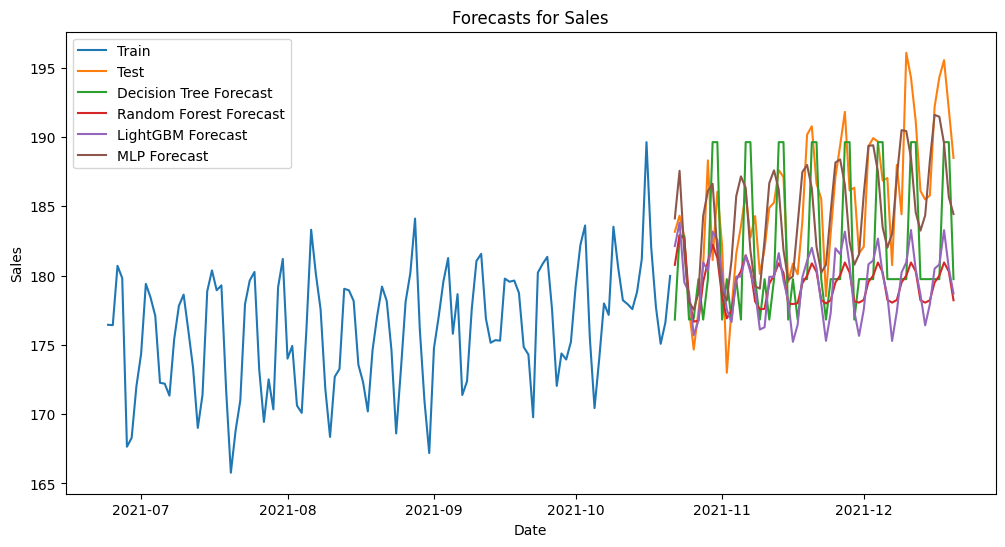

In [6]:
## plot the forecasts and the actual values for sales
plt.figure(figsize=(12, 6))
plt.plot(mv_train_data.index[-120:], mv_train_data['sales'][-120:], label='Train')
plt.plot(mv_test_data.index, mv_test_data['sales'], label='Test')
plt.plot(mv_test_data.index, dt_forecasts['sales'], label='Decision Tree Forecast')
plt.plot(mv_test_data.index, rf_forecasts['sales'], label='Random Forest Forecast')
plt.plot(mv_test_data.index, lgbm_forecasts['sales'], label='LightGBM Forecast')
plt.plot(mv_test_data.index, mlp_forecasts['sales'], label='MLP Forecast')
plt.title('Forecasts for Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

From the plot above, while MLP captures the trend better than the other models in this case, decision tree, random forest, and LightGBM fail to capture the trend as they are not designed to capture trend in time series data. Let's difference sales series and try again. We can difference the series by passing differencing order to the `ml_mv_forecaster` as `differencing_order={'sales': 1, 'marketing': 1, 'advertising': 1}` as we confirm that all series are non-stationary with the ADF test below.

In [7]:
from peshbeen.statstools import unit_root_test
unit_root_test(multivariate_data['sales'])
unit_root_test(multivariate_data['marketing'])
unit_root_test(multivariate_data['advertising'])    

ADF p-value: 0.914411 and data is non-stationary at 5% significance level
ADF p-value: 0.937516 and data is non-stationary at 5% significance level
ADF p-value: 0.921366 and data is non-stationary at 5% significance level


(np.float64(0.9213662589709057), None)

ADF test results show that all series are non-stationary, confirming the need for differencing. Also after differencing, we can check if there is any significant cross-correlation between the differenced series with the `ccf_plot` function from `statsmodels` module. The plot below shows that there are significant cross-correlations at various lags, particularly between the differenced `sales` and `marketing` series, which suggests that including lagged values of `marketing` as features in the model for `sales` could improve forecasting performance. However, the differenced `advertising` series does not show significant cross-correlations with the `sales` series, except slightly at lag 1, 3, and 14, which may indicate that it has less predictive power for `sales` compared to `marketing`. Therefore, we can consider including lagged values of `marketing` in the model for `sales`, while being more cautious about including lagged values of `advertising` due to the weaker cross-correlation.

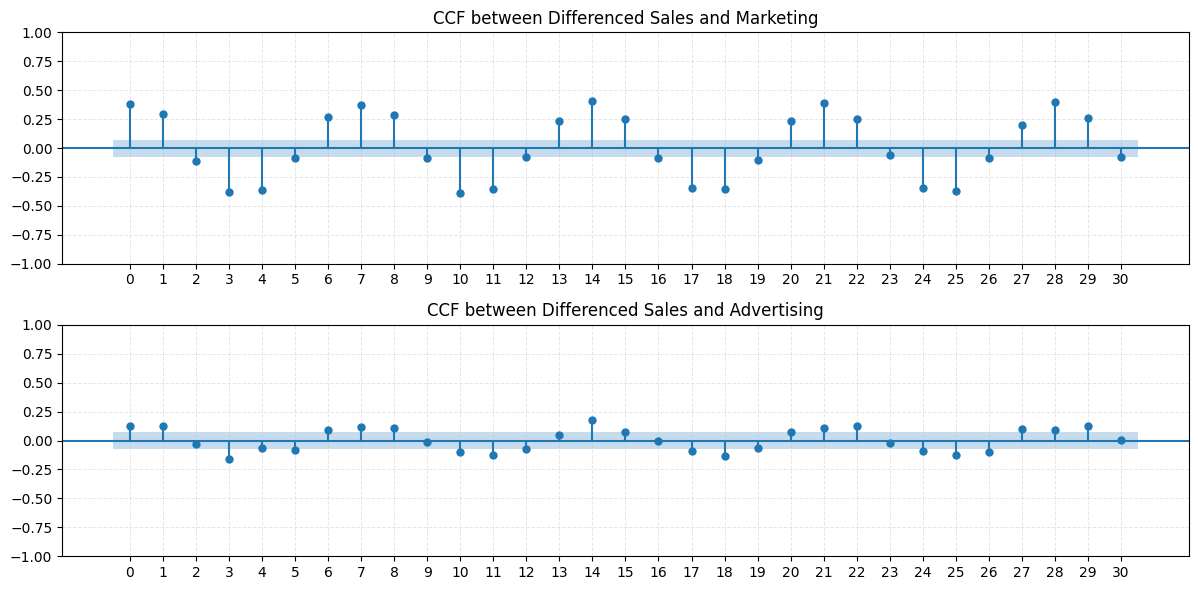

In [8]:
# also let's check the cross-correlation between the differenced sales and marketing series to see if there is any lagged relationship between them that we can capture with our models. We can use the `plot_ccf` function from `peshbeen.statsplots` to visualize the cross-correlation function (CCF) between the two series.
from statsmodels.graphics.tsaplots import plot_ccf
# from matplotlib.ticker import MaxNLocator
diff_sales = multivariate_data['sales'].diff().dropna()
diff_marketing = multivariate_data['marketing'].diff().dropna()
diff_advertising = multivariate_data['advertising'].diff().dropna()

_, ax = plt.subplots(2, 1, figsize=(12, 6))
plot_ccf(diff_sales, diff_marketing, lags=30, ax=ax[0])
plot_ccf(diff_sales, diff_advertising, lags=30, ax=ax[1])
ax[0].set_title('CCF between Differenced Sales and Marketing')
ax[1].set_title('CCF between Differenced Sales and Advertising')
for a in ax:
    a.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
    a.set_xticks(np.arange(0, 31, 1))
plt.tight_layout()
plt.show()

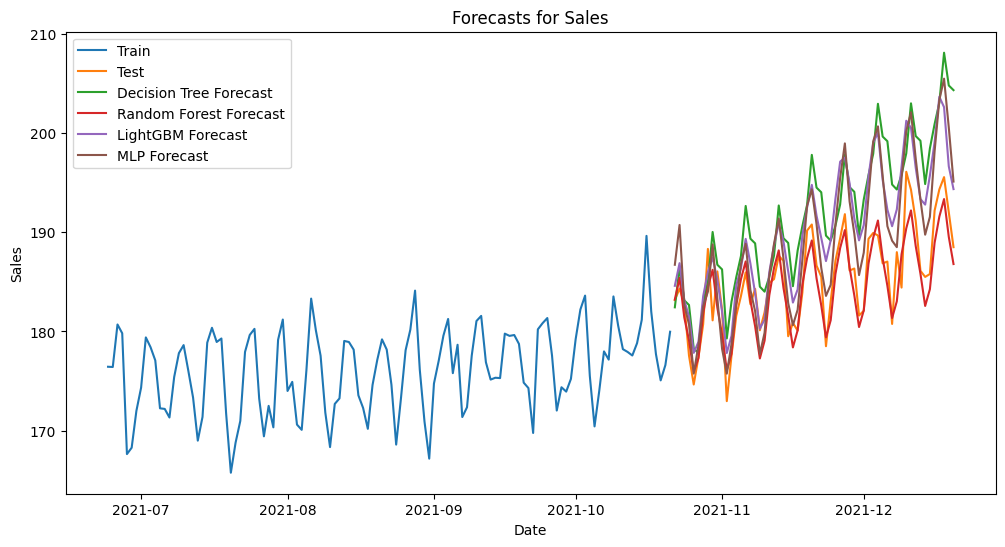

In [9]:
diff_lags = {'sales': 7, 'marketing': [1, 3, 4, 6, 7], 'advertising': [1, 3, 14]}
diff_dict = {'sales': 1, 'marketing': 1, 'advertising': 1}
## Decision Tree
dt_model_diff = ml_mv_forecaster(model=DecisionTreeRegressor(max_depth=7, random_state=123), target_cols=target_vars, lags=diff_lags,
                                 cat_variables=cat_vars, difference=diff_dict)
dt_model_diff.fit(mv_train_data)
dt_forecasts_diff = dt_model_diff.forecast(H=60, exog=mv_test_data[cat_vars])

## Random Forest
rf_model_diff = ml_mv_forecaster(model=RandomForestRegressor(n_estimators=100, max_depth=7, random_state=123), target_cols=target_vars, lags=diff_lags,
                                 cat_variables=cat_vars, difference=diff_dict)
rf_model_diff.fit(mv_train_data)
rf_forecasts_diff = rf_model_diff.forecast(H=60, exog=mv_test_data[cat_vars])

## LightGBM
lgbm_model_diff = ml_mv_forecaster(model=LGBMRegressor(n_estimators=100, max_depth=7, verbose=-1, random_state=123), target_cols=target_vars,
                                   lags=diff_lags, cat_variables=cat_vars, difference=diff_dict)
lgbm_model_diff.fit(mv_train_data)
lgbm_forecasts_diff = lgbm_model_diff.forecast(H=60, exog=mv_test_data[cat_vars])

## MLP
mlp_model_diff = ml_mv_forecaster(model=MLPRegressor(hidden_layer_sizes=(64, 32), random_state=123), target_cols=target_vars,
                                  lags=diff_lags, cat_variables=cat_vars, difference=diff_dict)
mlp_model_diff.fit(mv_train_data)
mlp_forecasts_diff = mlp_model_diff.forecast(H=60, exog=mv_test_data[cat_vars])

## plot the forecasts and the actual values for sales
plt.figure(figsize=(12, 6))
plt.plot(mv_train_data.index[-120:], mv_train_data['sales'][-120:], label='Train')
plt.plot(mv_test_data.index, mv_test_data['sales'], label='Test')
plt.plot(mv_test_data.index, dt_forecasts_diff['sales'], label='Decision Tree Forecast')
plt.plot(mv_test_data.index, rf_forecasts_diff['sales'], label='Random Forest Forecast')
plt.plot(mv_test_data.index, lgbm_forecasts_diff['sales'], label='LightGBM Forecast')
plt.plot(mv_test_data.index, mlp_forecasts_diff['sales'], label='MLP Forecast')
plt.title('Forecasts for Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

From the plot above, all models, including decision tree-based models, capture the trend better than before, especially Random Forest after differencing. We can also pass `trend = {'sales': 'linear', 'marketing': 'ets', 'advertising': 'linear'}` to the `ml_mv_forecaster` to explicitly model the trend in the data.